

## Control Group Feasibility Check

### **Question**

Are the treated states (**CA, FL, UT**) similar enough to the control (**AZ**) on socioeconomic, demographic, and climate dimensions to support a DiD design?

Additionally, are there other U.S. states with a similar climate to AZ that could serve as better controls?


### **Data Used**

* `data/processed/population/` — County population (2020–2024)
* `data/processed/socioeconomic/` — ACS county-level controls (2023 cross-section)
* `data/raw/weather/comparison_states_daily_weather_2021_2024.csv` — ERA5 daily weather data for 12 states (AZ + 11 candidate states)

### **What to Look For**

We need AZ and treated states to be *plausibly comparable* — not identical, but sufficiently similar such that the **parallel trends assumption** is defensible.

* **Socioeconomic & Demographic:** Comparable distributions (e.g., income, population structure)
* **Climate:** Identify candidate states whose **seasonal weather patterns** most closely track Arizona



In [25]:
import warnings

warnings.filterwarnings("ignore")

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# Find project root
_root = Path.cwd()
for _ in range(4):
    if (_root / "data").exists() and (_root / "scripts").exists():
        break
    _root = _root.parent
os.chdir(_root)

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

STATES = ["AZ", "CA", "FL", "UT"]
COLORS = {"AZ": "#e377c2", "CA": "#1f77b4", "FL": "#ff7f0e", "UT": "#2ca02c"}
print("Working dir:", Path.cwd())

Working dir: /Users/shellyy/Desktop/IDS_701/IDS701_UDS_Final_Project


In [26]:
pop = pd.read_csv(
    "data/processed/population/focus_states_county_population_2020_2024_long.csv",
    dtype=str,
)
pop["population"] = pd.to_numeric(pop["population"], errors="coerce")
pop["data_year"] = pd.to_numeric(pop["data_year"], errors="coerce")
pop["proposal_excluded_az_county"] = (
    pop["proposal_excluded_az_county"].map({"True": True, "False": False}).fillna(False)
)

acs = pd.read_csv(
    "data/processed/socioeconomic/acs_county_controls_derived_2021_2024.csv", dtype=str
)
acs["data_year"] = pd.to_numeric(acs["data_year"], errors="coerce")
for col in [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")
# Census uses -666666666 as "not available" sentinel
acs["median_household_income"] = acs["median_household_income"].where(
    acs["median_household_income"] > 0
)

# ERA5 comparison weather — 12 states, one representative point each
cw = pd.read_csv(
    "data/raw/weather/comparison_states_daily_weather_2021_2024.csv", dtype=str
)
cw["date"] = pd.to_datetime(cw["date"], errors="coerce")
for col in [
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "precipitation_sum",
]:
    cw[col] = pd.to_numeric(cw[col], errors="coerce")
cw["month"] = cw["date"].dt.month
cw["year"] = cw["date"].dt.year

# 2023 ACS; exclude AZ contaminated counties
acs23 = acs[acs["data_year"] == 2023].copy()
az_excluded = pop[pop["proposal_excluded_az_county"] == True]["county_fips"].unique()
acs23_clean = acs23[
    ~((acs23["state"] == "AZ") & (acs23["county_fips"].isin(az_excluded)))
]
pop23 = pop[
    (pop["data_year"] == 2023)
    & ~((pop["state"] == "AZ") & (pop["proposal_excluded_az_county"] == True))
]

# All states present in data
CANDIDATE_STATES = sorted(cw["state"].unique())
STUDY_STATES = {"AZ", "CA", "FL", "UT"}

# Color palette: study states keep their colors, candidates get grays/muted tones
import matplotlib.cm as cm

_tab20 = cm.get_cmap("tab20")
_extra = [_tab20(i / 16) for i in range(16)]
_cand_list = [s for s in CANDIDATE_STATES if s not in COLORS]
CAND_COLORS = {**COLORS, **{s: _extra[i] for i, s in enumerate(_cand_list)}}

print("All states:", CANDIDATE_STATES)
print("ACS 2023 counties per state:", acs23_clean.groupby("state").size().to_dict())

All states: ['AZ', 'CA', 'CO', 'FL', 'ID', 'MT', 'NM', 'NV', 'OR', 'TX', 'UT', 'WY']
ACS 2023 counties per state: {'AZ': 12, 'CA': 58, 'CO': 64, 'FL': 67, 'ID': 44, 'MT': 56, 'NM': 33, 'NV': 17, 'OR': 36, 'TX': 254, 'UT': 29, 'WY': 23}


## Part 1 — Population

County-level population distributions for all 12 states. Study states (AZ, CA, FL, UT) shown with bold outlines. We expect CA and TX to be much larger (many populous counties); the question is whether AZ, UT, NM, NV, and other candidates have overlapping county-size profiles.

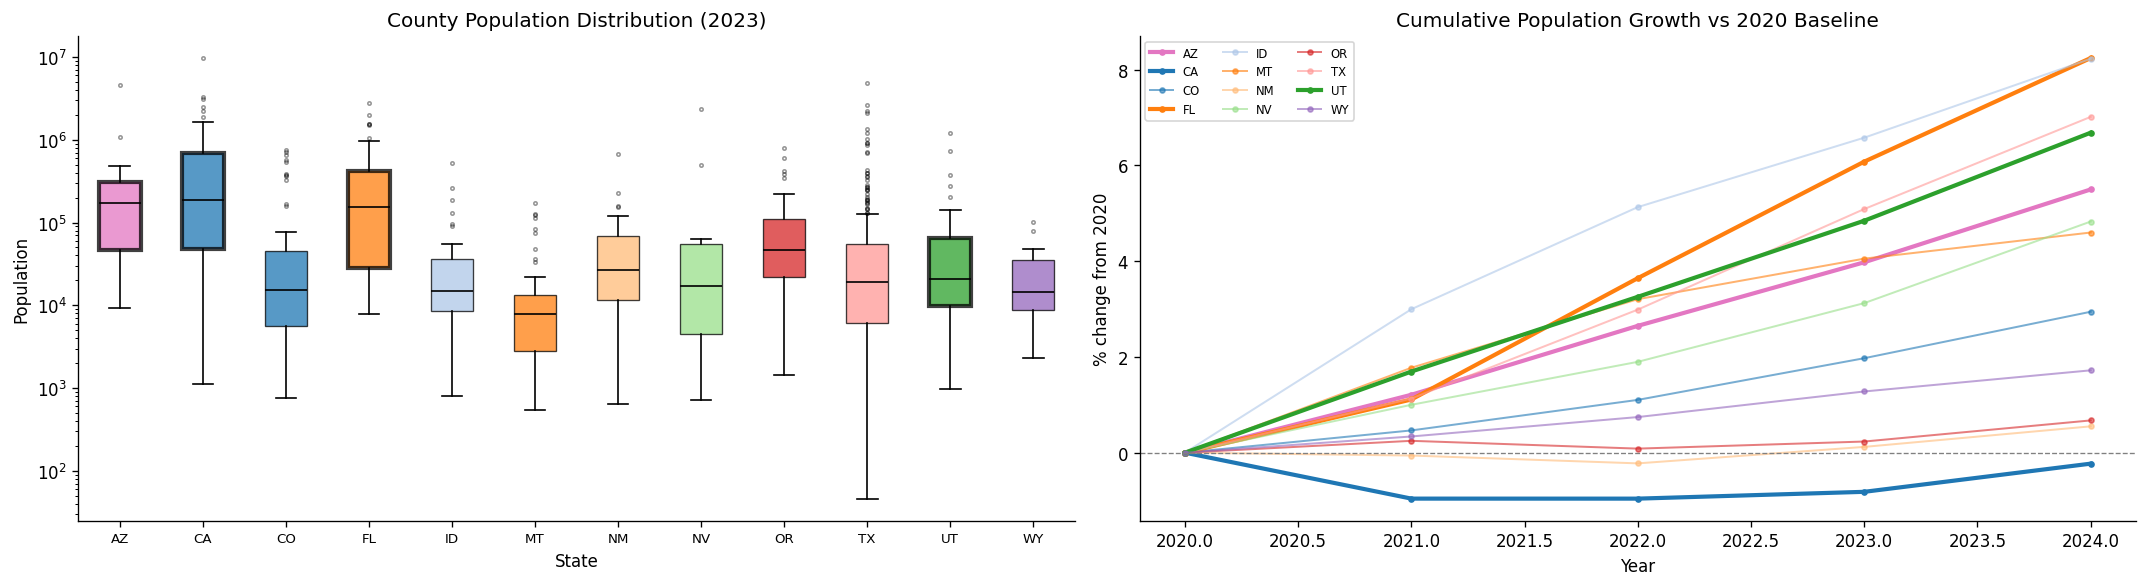

       Median county pop  Mean county pop  Total state pop
state                                                     
CA                186548           675839         39198693
TX                 18896           120975         30727890
FL                152157           341863         22904868
AZ                170164           596140          7153691
CO                 15182            92208          5901339
OR                 46198           118157          4253653
UT                 20607           118731          3443222
NV                 17160           189080          3214363
NM                 26633            64277          2121164
ID                 14887            44798          1971122
MT                  7769            20201          1131302
WY                 14317            25437           585067


In [27]:
ALL_STATES = sorted(pop23["state"].unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: box plot of county population — all 12 states
ax = axes[0]
data = [pop23[pop23["state"] == s]["population"].dropna().values for s in ALL_STATES]
bp = ax.boxplot(
    data,
    labels=ALL_STATES,
    patch_artist=True,
    medianprops={"color": "black"},
    showfliers=True,
    flierprops={"markersize": 2, "alpha": 0.4},
)
for patch, s in zip(bp["boxes"], ALL_STATES):
    patch.set_facecolor(CAND_COLORS.get(s, "gray"))
    patch.set_alpha(0.75)
    patch.set_linewidth(2.5 if s in STUDY_STATES else 0.8)
ax.set_title("County Population Distribution (2023)")
ax.set_ylabel("Population")
ax.set_yscale("log")
ax.set_xlabel("State")
ax.tick_params(axis="x", labelsize=8)

# Right: population growth 2020→2023
ax = axes[1]
for s in ALL_STATES:
    sub = pop[pop["state"] == s].groupby("data_year")["population"].sum().reset_index()
    base_row = sub[sub["data_year"] == 2020]["population"]
    if base_row.empty:
        continue
    base = base_row.values[0]
    lw = 2.5 if s in STUDY_STATES else 1.2
    alpha = 1.0 if s in STUDY_STATES else 0.6
    ax.plot(
        sub["data_year"],
        sub["population"] / base * 100 - 100,
        marker="o",
        markersize=3,
        label=s,
        color=CAND_COLORS.get(s, "gray"),
        lw=lw,
        alpha=alpha,
    )
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Population Growth vs 2020 Baseline")
ax.set_ylabel("% change from 2020")
ax.set_xlabel("Year")
ax.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.show()

# Summary table
summary = (
    pop23.groupby("state")["population"].agg(["median", "mean", "sum"]).astype(int)
)
summary.columns = ["Median county pop", "Mean county pop", "Total state pop"]
print(summary.sort_values("Total state pop", ascending=False).to_string())

## Part 2 — Socioeconomic Comparison

Four ACS variables at county level (2023) for all 12 states. AZ is the benchmark. Box plots show distribution overlap; the table shows medians and KS-test p-values vs AZ. Study states (CA, FL, UT) are highlighted; candidate controls (NM, NV, TX, CO, ID, WY, OR, MT) are in muted colors.

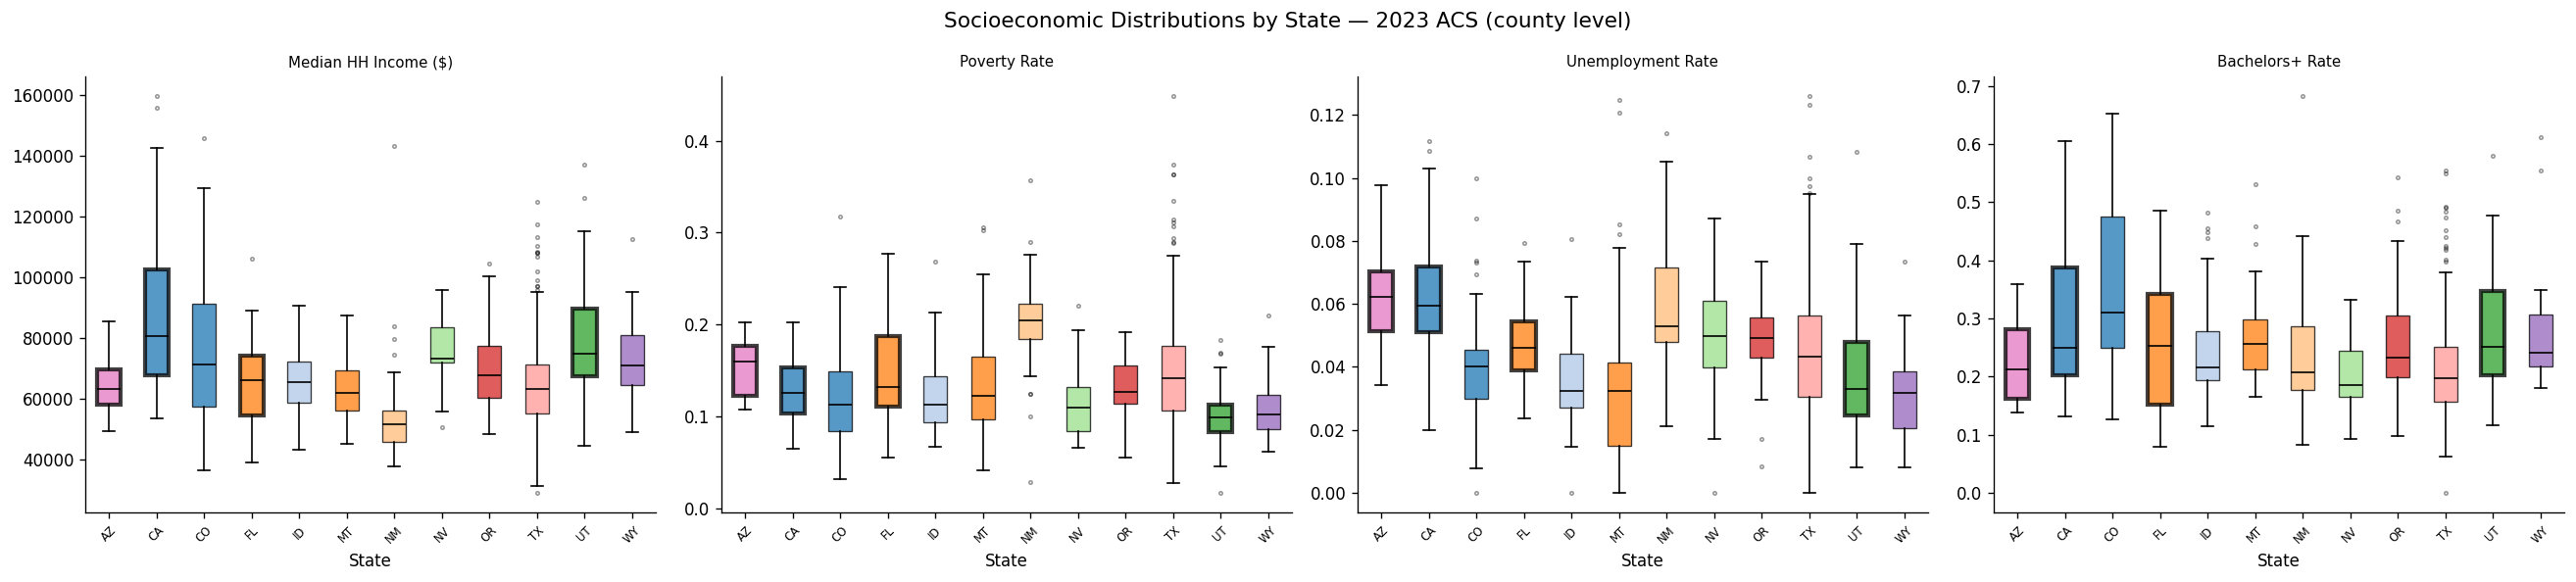


Median values and KS-test p-value vs AZ (2023):
                           AZ         CA        CO        FL        ID        MT         NM         NV        OR        TX         UT        WY
Variable                                                                                                                                       
Median HH Income ($)  $63,262  $80,702 *   $71,230   $66,154   $65,530   $61,858  $51,765 *  $73,364 *   $67,628   $63,367  $75,000 *   $70,855
Poverty Rate           0.1600     0.1257  0.1131 *    0.1320  0.1126 *    0.1223   0.2045 *     0.1103    0.1271    0.1420   0.0988 *  0.1022 *
Unemployment Rate      0.0622     0.0595  0.0403 *  0.0461 *  0.0324 *  0.0322 *     0.0530     0.0497  0.0492 *  0.0432 *   0.0331 *  0.0317 *
Bachelors+ Rate        0.2128     0.2500  0.3096 *    0.2531    0.2161    0.2571     0.2081     0.1861    0.2335    0.1969     0.2519    0.2412

* = significantly different distribution from AZ (KS test p < 0.05)


In [28]:
VARS = [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
]
LABELS = [
    "Median HH Income ($)",
    "Poverty Rate",
    "Unemployment Rate",
    "Bachelors+ Rate",
]

ALL_SES_STATES = sorted(acs23_clean["state"].unique())
az_vals = {
    v: acs23_clean[acs23_clean["state"] == "AZ"][v].dropna().values for v in VARS
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    "Socioeconomic Distributions by State — 2023 ACS (county level)", fontsize=13
)

for ax, var, label in zip(axes, VARS, LABELS):
    data = [
        acs23_clean[acs23_clean["state"] == s][var].dropna().values
        for s in ALL_SES_STATES
    ]
    bp = ax.boxplot(
        data,
        labels=ALL_SES_STATES,
        patch_artist=True,
        medianprops={"color": "black"},
        showfliers=True,
        flierprops={"markersize": 2, "alpha": 0.4},
    )
    for patch, s in zip(bp["boxes"], ALL_SES_STATES):
        patch.set_facecolor(CAND_COLORS.get(s, "gray"))
        patch.set_alpha(0.75)
        patch.set_linewidth(2.5 if s in STUDY_STATES else 0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("State")
    ax.tick_params(axis="x", labelsize=7, rotation=45)

plt.tight_layout()
plt.show()

# Median table + KS test vs AZ
print("\nMedian values and KS-test p-value vs AZ (2023):")
rows = []
for var, label in zip(VARS, LABELS):
    az = az_vals[var]
    row = {"Variable": label}
    for s in ALL_SES_STATES:
        vals = acs23_clean[acs23_clean["state"] == s][var].dropna().values
        median = np.median(vals)
        if s == "AZ":
            row[s] = (
                f"{median:.4f}"
                if var != "median_household_income"
                else f"${median:,.0f}"
            )
        else:
            ks_p = stats.ks_2samp(az, vals).pvalue
            flag = " *" if ks_p < 0.05 else ""
            fmt = (
                f"{median:.4f}"
                if var != "median_household_income"
                else f"${median:,.0f}"
            )
            row[s] = f"{fmt}{flag}"
    rows.append(row)

tbl = pd.DataFrame(rows).set_index("Variable")
print(tbl.to_string())
print("\n* = significantly different distribution from AZ (KS test p < 0.05)")

## Part 3 — Climate Comparison: Monthly Patterns

Monthly average temperature and precipitation for all 12 candidate states vs AZ. The study states (AZ, CA, FL, UT) are highlighted in bold colors; candidate controls are shown in lighter tones.

Key question: Which candidate states track AZ's seasonal temperature and precipitation pattern most closely? A good control state should show a similar *shape* of seasonal variation, even if the absolute level differs slightly.

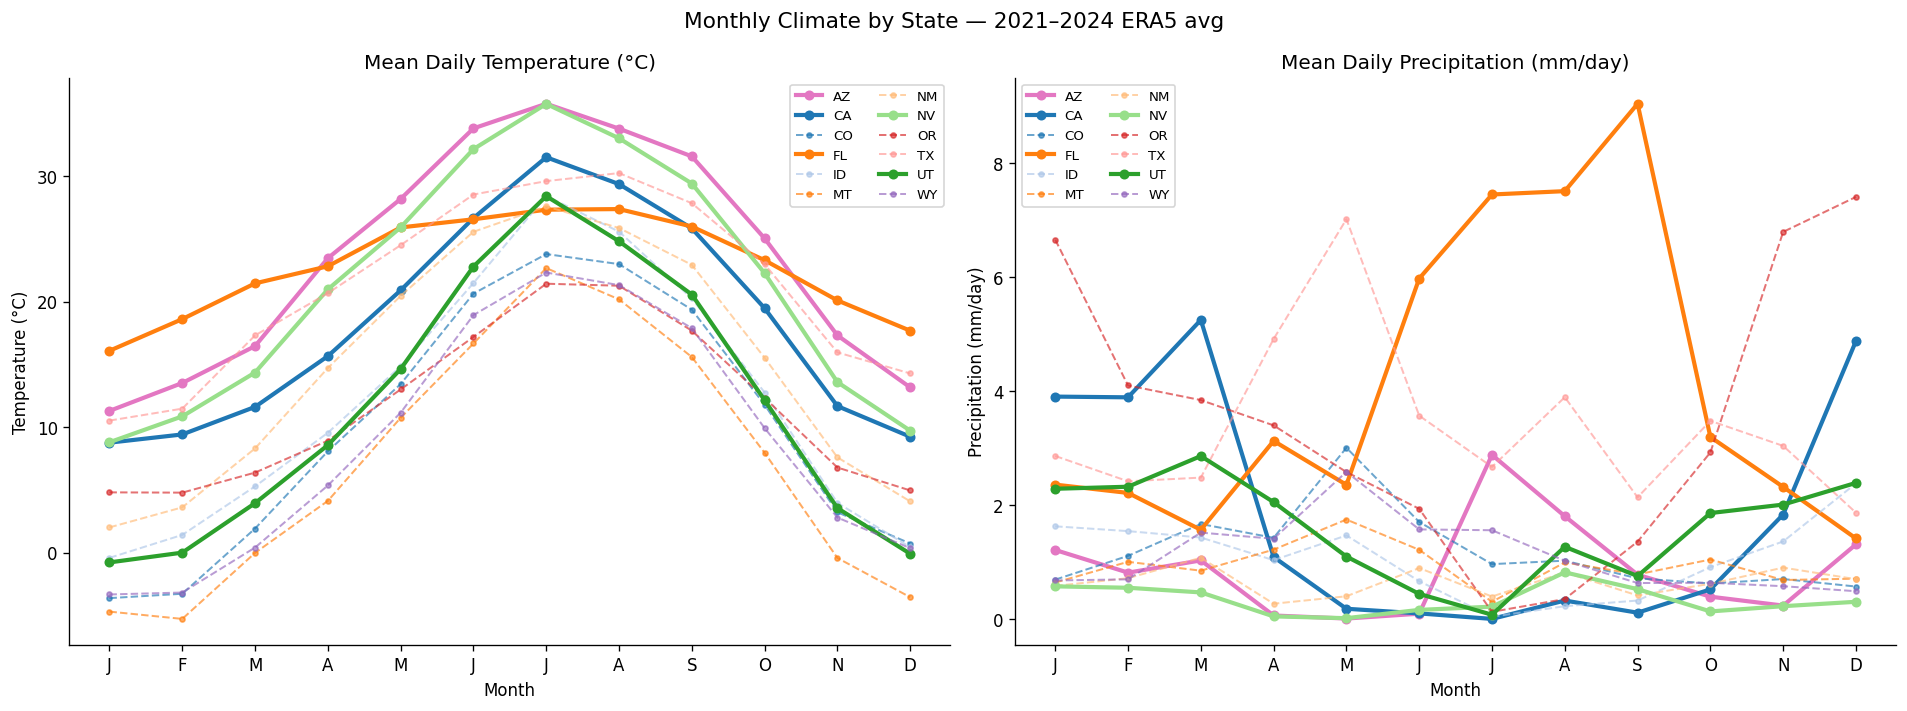

Annual climate summary (ERA5 representative point, 2021–2024):
      temperature_2m_mean        precipitation_sum      
                     mean    std              mean   std
state                                                   
AZ                  23.66   9.27              0.89  4.36
CA                  18.40   8.71              1.84  6.91
CO                   9.99  10.61              1.18  3.61
FL                  22.79   4.66              4.05  8.54
ID                  12.03  10.53              1.08  2.61
MT                   7.07  11.00              0.93  2.26
NM                  14.91   9.70              0.65  2.13
NV                  21.46  10.07              0.33  1.91
OR                  11.67   6.97              3.45  6.83
TX                  21.22   7.96              3.37  8.13
UT                  11.61  10.91              1.62  3.82
WY                   8.73  10.37              1.12  3.02


In [32]:
monthly_climate = (
    cw.groupby(["state", "month"])[["temperature_2m_mean", "precipitation_sum"]]
    .mean()
    .reset_index()
)

# Line widths: study states thick, candidates thin
STUDY_STATES = {"AZ", "CA", "FL", "UT", "NV"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Monthly Climate by State — 2021–2024 ERA5 avg", fontsize=13)

for state in CANDIDATE_STATES:
    sub = monthly_climate[monthly_climate["state"] == state].sort_values("month")
    lw = 2.5 if state in STUDY_STATES else 1.2
    ls = "-" if state in STUDY_STATES else "--"
    alpha = 1.0 if state in STUDY_STATES else 0.65
    color = CAND_COLORS[state]
    label = f"**{state}**" if state in STUDY_STATES else state

    axes[0].plot(
        sub["month"],
        sub["temperature_2m_mean"],
        marker="o",
        markersize=3 if state not in STUDY_STATES else 5,
        label=state,
        color=color,
        lw=lw,
        ls=ls,
        alpha=alpha,
    )
    axes[1].plot(
        sub["month"],
        sub["precipitation_sum"],
        marker="o",
        markersize=3 if state not in STUDY_STATES else 5,
        label=state,
        color=color,
        lw=lw,
        ls=ls,
        alpha=alpha,
    )

for ax, title, ylabel in zip(
    axes,
    ["Mean Daily Temperature (°C)", "Mean Daily Precipitation (mm/day)"],
    ["Temperature (°C)", "Precipitation (mm/day)"],
):
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Annual summary table
print("Annual climate summary (ERA5 representative point, 2021–2024):")
print(
    cw.groupby("state")[["temperature_2m_mean", "precipitation_sum"]]
    .agg(["mean", "std"])
    .round(2)
    .to_string()
)

## Part 4 — Climate Similarity Ranking vs AZ

Quantitative ranking of all 12 states by climate similarity to AZ using three metrics:

1. **KS statistic (temperature)** — distance between daily temperature distributions (lower = more similar)
2. **Monthly temp correlation** — Pearson r between monthly mean temperatures (higher = more similar seasonal shape)
3. **Monthly precip correlation** — same for precipitation

A composite similarity score combines all three. NM and NV are expected to rank highest given their desert Southwest geography.

Climate Similarity Ranking vs AZ (higher score = more similar):

   state  ks_temp  monthly_temp_r  monthly_precip_r  composite_score  study_state
1     NV    0.141           0.998             0.471            0.990         True
2     NM    0.329           0.998            -0.035            0.699        False
3     CA    0.223           0.986             0.081            0.666         True
4     TX    0.201           0.989            -0.460            0.566        False
5     FL    0.339           0.978             0.393            0.543         True
6     UT    0.442           0.988            -0.243            0.413         True
7     CO    0.452           0.992            -0.385            0.410        False
8     ID    0.435           0.985            -0.330            0.361        False
9     WY    0.491           0.984            -0.133            0.353        False
10    MT    0.533           0.987            -0.723            0.194        False
11    OR    0.481           0.972

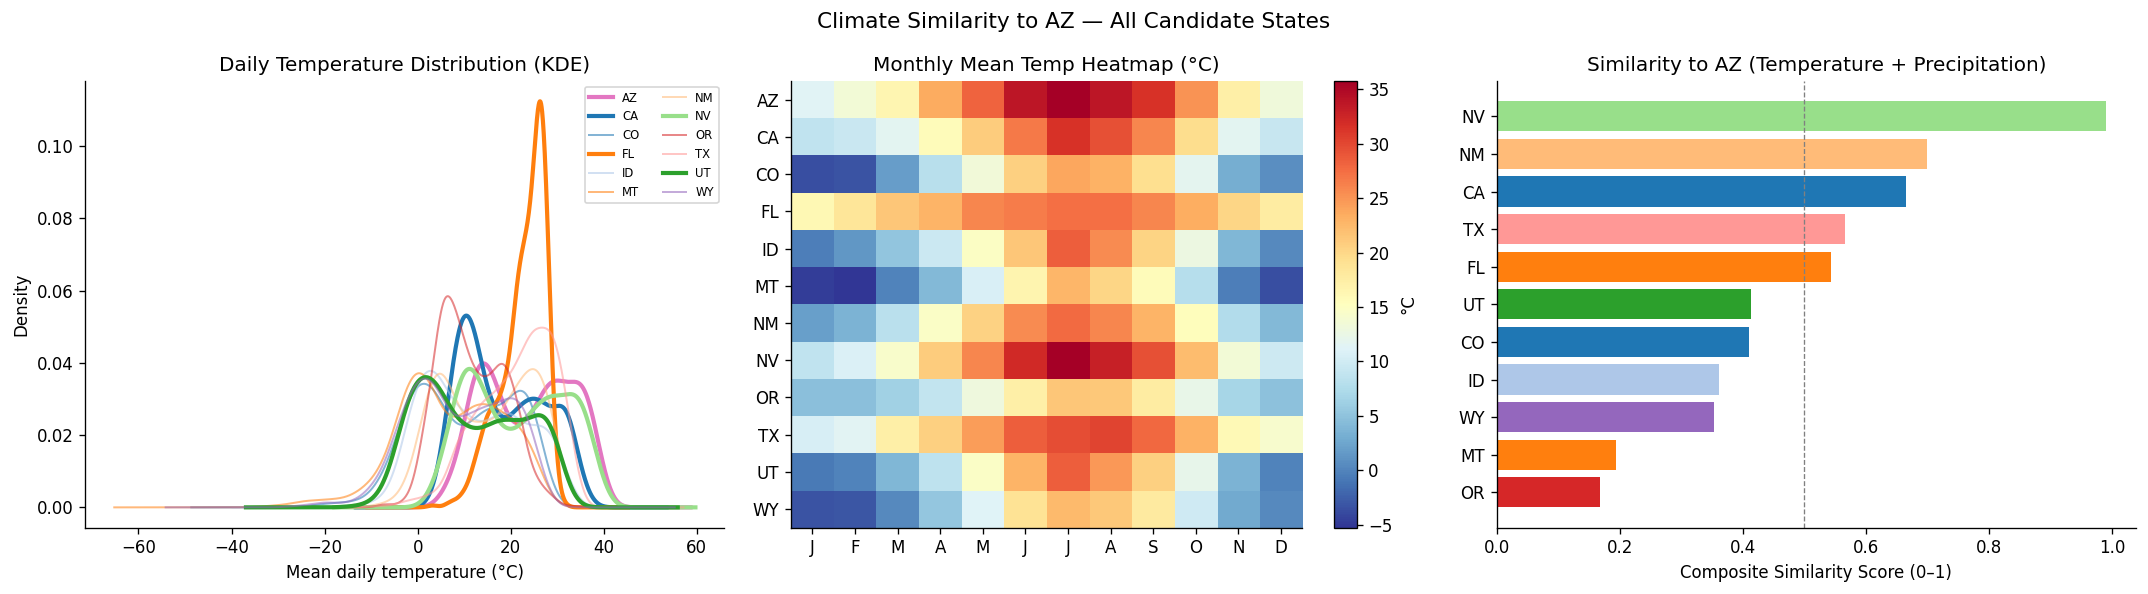

In [38]:
from scipy.stats import pearsonr

az_temps = cw[cw["state"] == "AZ"]["temperature_2m_mean"].dropna().values
az_precip = cw[cw["state"] == "AZ"]["precipitation_sum"].dropna().values
az_monthly_temp = (
    monthly_climate[monthly_climate["state"] == "AZ"]
    .sort_values("month")["temperature_2m_mean"]
    .values
)
az_monthly_precip = (
    monthly_climate[monthly_climate["state"] == "AZ"]
    .sort_values("month")["precipitation_sum"]
    .values
)

rows = []
for state in [s for s in CANDIDATE_STATES if s != "AZ"]:
    s_temps = cw[cw["state"] == state]["temperature_2m_mean"].dropna().values
    ks_stat = stats.ks_2samp(az_temps, s_temps).statistic

    s_monthly_temp = (
        monthly_climate[monthly_climate["state"] == state]
        .sort_values("month")["temperature_2m_mean"]
        .values
    )
    s_monthly_precip = (
        monthly_climate[monthly_climate["state"] == state]
        .sort_values("month")["precipitation_sum"]
        .values
    )

    temp_r = (
        pearsonr(az_monthly_temp, s_monthly_temp)[0]
        if len(s_monthly_temp) == 12
        else np.nan
    )
    precip_r = (
        pearsonr(az_monthly_precip, s_monthly_precip)[0]
        if len(s_monthly_precip) == 12
        else np.nan
    )

    rows.append(
        {
            "state": state,
            "ks_temp": ks_stat,
            "monthly_temp_r": temp_r,
            "monthly_precip_r": precip_r,
            "study_state": state in STUDY_STATES,
        }
    )

ranking = pd.DataFrame(rows)
# Normalize: ks lower is better → invert; correlations higher is better
ranking["ks_norm"] = 1 - (ranking["ks_temp"] - ranking["ks_temp"].min()) / (
    ranking["ks_temp"].max() - ranking["ks_temp"].min()
)
ranking["temp_r_norm"] = (
    ranking["monthly_temp_r"] - ranking["monthly_temp_r"].min()
) / (ranking["monthly_temp_r"].max() - ranking["monthly_temp_r"].min())
ranking["precip_r_norm"] = (
    ranking["monthly_precip_r"] - ranking["monthly_precip_r"].min()
) / (ranking["monthly_precip_r"].max() - ranking["monthly_precip_r"].min())
ranking["composite_score"] = (
    ranking["ks_norm"] + ranking["temp_r_norm"] + ranking["precip_r_norm"]
) / 3
ranking = ranking.sort_values("composite_score", ascending=False).reset_index(drop=True)
ranking.index += 1

print("Climate Similarity Ranking vs AZ (higher score = more similar):\n")
display_cols = [
    "state",
    "ks_temp",
    "monthly_temp_r",
    "monthly_precip_r",
    "composite_score",
    "study_state",
]
print(ranking[display_cols].to_string(float_format=lambda x: f"{x:.3f}"))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Climate Similarity to AZ — All Candidate States", fontsize=13)

# 1. Temperature KDE
ax = axes[0]
for state in CANDIDATE_STATES:
    temps = cw[cw["state"] == state]["temperature_2m_mean"].dropna()
    lw = 2.5 if state in STUDY_STATES else 1.2
    alpha = 1.0 if state in STUDY_STATES else 0.55
    temps.plot.kde(
        ax=ax, label=state, color=CAND_COLORS[state], linewidth=lw, alpha=alpha
    )
ax.set_title("Daily Temperature Distribution (KDE)")
ax.set_xlabel("Mean daily temperature (°C)")
ax.set_ylabel("Density")
ax.legend(fontsize=7, ncol=2)

# 2. Monthly temperature heatmap (all states × months)
ax = axes[1]
pivot_temp = monthly_climate.pivot(
    index="state", columns="month", values="temperature_2m_mean"
)
im = ax.imshow(pivot_temp.values, aspect="auto", cmap="RdYlBu_r")
ax.set_xticks(range(12))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_yticks(range(len(pivot_temp.index)))
ax.set_yticklabels(pivot_temp.index)
ax.set_title("Monthly Mean Temp Heatmap (°C)")
plt.colorbar(im, ax=ax, label="°C")

# 3. Composite similarity bar chart
ax = axes[2]
colors_bar = [CAND_COLORS.get(s, "steelblue") for s in ranking["state"]]
bars = ax.barh(
    ranking["state"][::-1], ranking["composite_score"][::-1], color=colors_bar[::-1]
)
ax.set_xlabel("Composite Similarity Score (0–1)")
ax.set_title("Similarity to AZ (Temperature + Precipitation)")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)


plt.tight_layout()
plt.show()

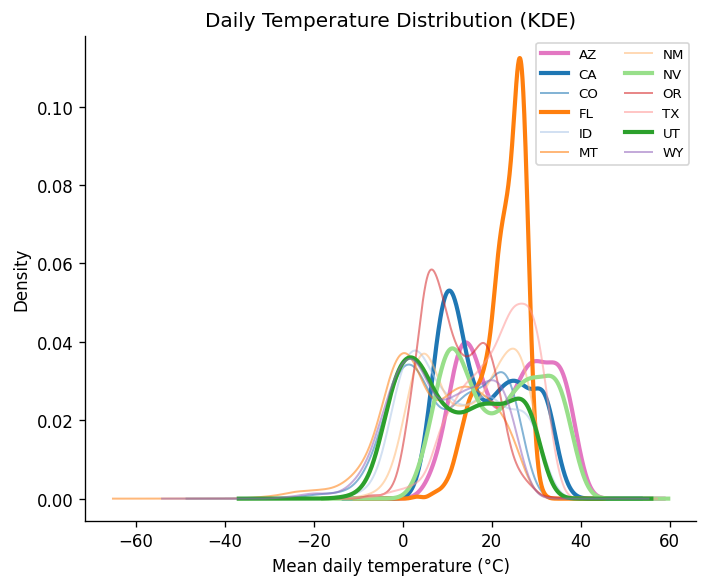

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))

for state in CANDIDATE_STATES:
    temps = cw[cw["state"] == state]["temperature_2m_mean"].dropna()
    lw = 2.5 if state in STUDY_STATES else 1.2
    alpha = 1.0 if state in STUDY_STATES else 0.55

    temps.plot.kde(
        ax=ax, label=state, color=CAND_COLORS[state], linewidth=lw, alpha=alpha
    )

ax.set_title("Daily Temperature Distribution (KDE)")
ax.set_xlabel("Mean daily temperature (°C)")
ax.set_ylabel("Density")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

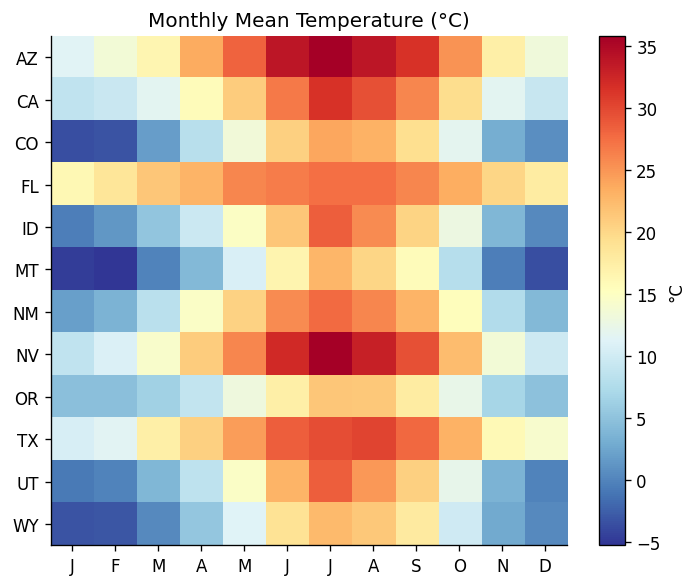

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))

pivot_temp = monthly_climate.pivot(
    index="state", columns="month", values="temperature_2m_mean"
)

im = ax.imshow(pivot_temp.values, aspect="auto", cmap="RdYlBu_r")

ax.set_xticks(range(12))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])

ax.set_yticks(range(len(pivot_temp.index)))
ax.set_yticklabels(pivot_temp.index)

ax.set_title("Monthly Mean Temperature (°C)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("°C")

plt.tight_layout()
plt.show()

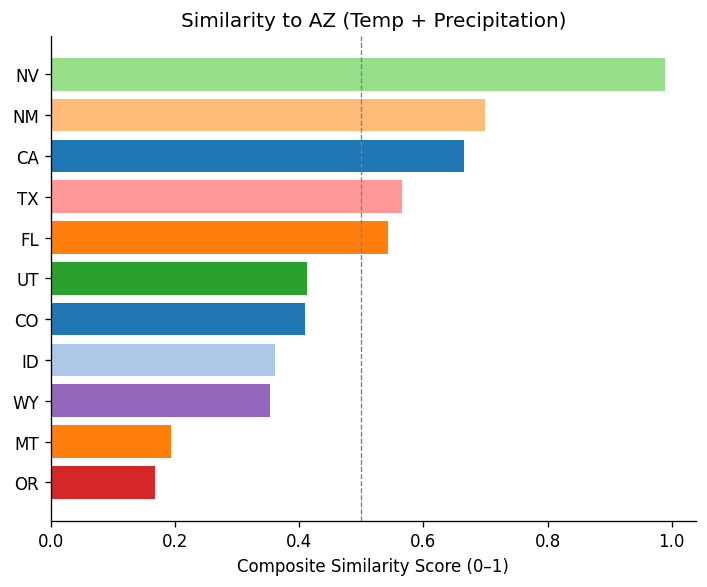

In [37]:
fig, ax = plt.subplots(figsize=(6, 5))

colors_bar = [CAND_COLORS.get(s, "steelblue") for s in ranking["state"]]

bars = ax.barh(
    ranking["state"][::-1], ranking["composite_score"][::-1], color=colors_bar[::-1]
)

ax.set_xlabel("Composite Similarity Score (0–1)")
ax.set_title("Similarity to AZ (Temp + Precipitation)")

ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)


plt.tight_layout()
plt.show()

## Summary

### Final Design: CA + NV (treated) vs AZ (control)

| Dimension | CA vs AZ | NV vs AZ |
|---|---|---|
| Total state pop | 39.2M vs 7.2M — larger, but manageable with county-level DiD | 3.2M vs 7.2M — similar scale |
| Median county pop | 187K vs 170K — close | 17K vs 170K — smaller counties |
| Median income | $80,702 * sig diff | $73,364 * sig diff |
| Poverty rate | 0.126 — not sig diff ✓ | 0.110 — not sig diff ✓ |
| Unemployment | 0.060 — not sig diff ✓ | 0.050 — not sig diff ✓ |
| Education (BA+) | 0.250 — not sig diff ✓ | 0.186 — not sig diff ✓ |
| Climate similarity to AZ | 0.666 — moderate (Central Valley) | **0.990 — near-identical (Las Vegas ≈ Phoenix)** |
| Temperature seasonality | Similar shape, slightly cooler | Almost identical to AZ ✓ |
| Precipitation | Drier summers, wetter winters | Near-identical desert pattern ✓ |

### Why drop FL and UT?

| State | Reason for dropping |
|---|---|
| FL | Humid subtropical climate (similarity 0.543) — seasonal crime patterns driven by very different temperature/precipitation dynamics than AZ. Also unemployment sig diff from AZ. |
| UT | Weakest parallel trends case: **3 of 4** ACS variables significantly different from AZ (income, poverty, unemployment). Climate similarity only 0.413 — cold mountain winters break seasonal comparability. |

### Verdict

**CA + NV vs AZ is the strongest feasible DiD design given available data.**

- NV is climatically near-identical to AZ (score 0.990) and differs only on median income — the parallel trends assumption for crime seasonality is highly defensible.
- CA adds statistical power (58 counties, large NIBRS sample) with moderate climate overlap and only income differing significantly.
- AZ as control is ideal: no DST, desert Southwest, overlapping socioeconomic profile with NV on 3 of 4 dimensions.
- Income differences in both CA and NV vs AZ are noted but do not threaten parallel trends as long as income levels are included as controls in the regression.